In [ ]:

import sys
import os
sys.path.append(os.path.abspath(".."))

import yaml
from src.path import CONFIG_DIR

#Load config from YAML
with open(CONFIG_DIR / "data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

with open(CONFIG_DIR / "base.yaml", "r") as f:
    base_config = yaml.safe_load(f)

#Set random seed for reproducibility
random_seed = base_config["seed"]

import pandas as pd
import zipfile
import matplotlib.pyplot as plt

In [ ]:
from src.path import RAW_DATA_DIR

zf = zipfile.ZipFile(f"{RAW_DATA_DIR}/m5-forecasting-accuracy.zip")

#Filter only CA3 for testing
sales_ca3 = pd.read_csv(zf.open('sales_train_validation.csv')).query("store_id == 'CA_3'").copy()

calendar_val = pd.read_csv(zf.open('calendar.csv'))
sell_prices_val = pd.read_csv(zf.open('sell_prices.csv'))

In [ ]:
#Convert Wide to Long and add calendar and price dimensions
from src.data.make_dataset import melt_sales_to_long, add_dim_columns 

m5_config = data_config["m5"]
id_cols = m5_config["id_cols"]
join_key = m5_config["join_key_calendar"]
calendar_cols = m5_config["calendar_cols"]

# Add calendar
sales_long = melt_sales_to_long(sales_ca3, id_cols=id_cols, var_name='d', value_name='demand')

sales_with_calendar = add_dim_columns(
    sales_long,
    calendar_val,
    join_key=join_key,
    dim_cols=calendar_cols,
)

join_key = m5_config["join_key_price"]
price_cols = m5_config["price_cols"]

# Add sell_price to sales_with_calendar
sales_with_prices_calendar = add_dim_columns(
    sales_with_calendar,
    sell_prices_val,
    join_key=join_key,
    dim_cols=price_cols
).assign(revenue=lambda x: x["demand"] * x["sell_price"])

sales_with_prices_calendar.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,wm_yr_wk,date,sell_price,revenue
0,HOBBIES_1_001_CA_3_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,NaN,NaN
1,HOBBIES_1_002_CA_3_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,NaN,NaN
2,HOBBIES_1_003_CA_3_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,NaN,NaN
3,HOBBIES_1_004_CA_3_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,NaN,NaN
4,HOBBIES_1_005_CA_3_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_3,CA,d_1,0,11101,2011-01-29,NaN,NaN


In [ ]:
from src.features.build_features import create_sales_by_item_with_classification

# Classify demand
demand_classify = create_sales_by_item_with_classification(
    sales_with_prices_calendar, product_colID='item_id', totalsales_col='revenue', demand_col='demand')

demand_classify.head()

,item_id,revenue,ADI,CV2,demand_type
0,FOODS_3_120,442198.10,1.530400,0.283841,intermittent
1,FOODS_3_090,339060.48,1.231017,0.370897,smooth
2,FOODS_3_202,218819.78,1.060421,0.376163,smooth
3,FOODS_3_586,214319.58,1.002621,0.061261,smooth
4,FOODS_2_244,195579.76,1.047645,0.304107,smooth


In [ ]:
#Classify ABC by Kmeans
from src.features.build_features import classify_abc_by_kmeans

# Apply K-means ABC classification
ABC_demand_classify = classify_abc_by_kmeans(
    demand_classify,
    sales_col='revenue',
    n_clusters=3,
    random_state=random_seed
)

In [ ]:
ABC_demand_classify.head(5)

,item_id,revenue,ADI,CV2,demand_type,cluster_3,ABC_class
0,FOODS_3_120,442198.10,1.530400,0.283841,intermittent,0,A
1,FOODS_3_090,339060.48,1.231017,0.370897,smooth,0,A
2,FOODS_3_202,218819.78,1.060421,0.376163,smooth,0,A
3,FOODS_3_586,214319.58,1.002621,0.061261,smooth,0,A
4,FOODS_2_244,195579.76,1.047645,0.304107,smooth,0,A


In [ ]:
#Phân loại vòng đời sản phẩm
from src.features.build_features import classify_product_lifecycle, get_current_lifecycle_stage

# Apply lifecycle classification directly on daily sales data
annual_sales = classify_product_lifecycle(
    sales_with_prices_calendar,
    item_col='item_id',
    date_col='date',
    sales_col='revenue'
)


# Get current lifecycle stage as of 2015
current_stage_by_item = get_current_lifecycle_stage(
    annual_sales,
    year_col='year',
    item_col='item_id',
    as_of_year=2015
)

current_stage_by_item.head(5)

,item_id,year,annual_sales,pct_change,last_annual_sales,first_sales_year,life_cycle_stage
0,FOODS_1_001,2015,810.88,2.934904,787.76,2011,Stable maturity
1,FOODS_1_002,2015,1071.24,-32.360964,1583.76,2011,Decaying maturity
2,FOODS_1_003,2015,904.40,-32.175426,1333.44,2011,Decaying maturity
3,FOODS_1_004,2015,7810.60,7.890157,7239.40,2012,Sustained maturity
4,FOODS_1_005,2015,2446.14,55.040754,1577.74,2011,Growth


# Visualization

<Axes: title={'center': 'Number of items by Life Cycle Stage (as of now)'}, xlabel='life_cycle_stage'>

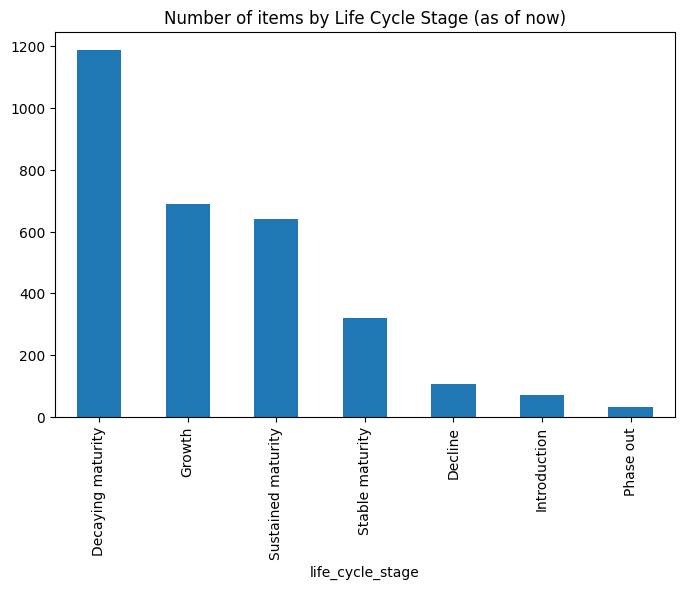

In [ ]:
current_stage_by_item.value_counts('life_cycle_stage').plot(kind='bar', figsize=(8,5), title='Number of items by Life Cycle Stage (as of now)')

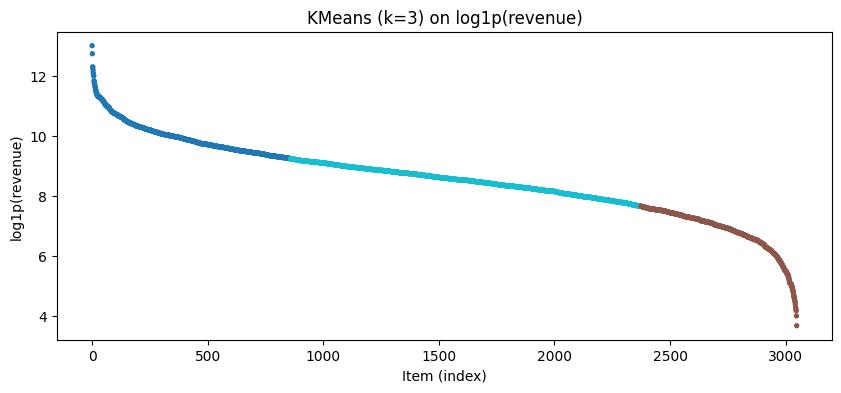

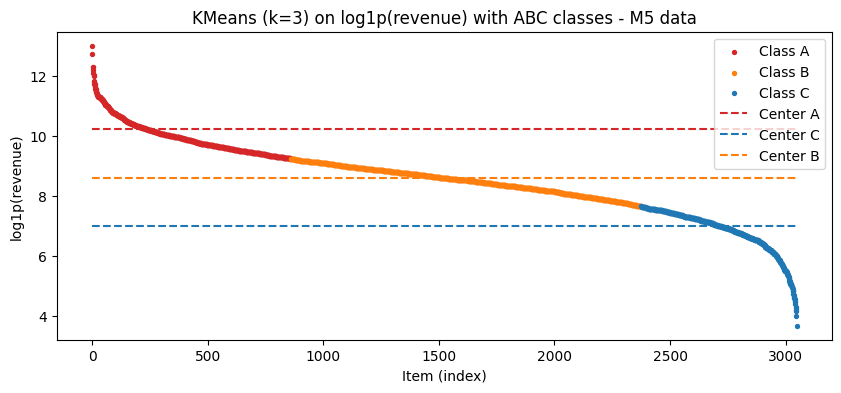

In [ ]:
import numpy as np

# Get cluster info for visualization
X_for_clust = np.log1p(ABC_demand_classify['revenue'].values).reshape(-1, 1)
labels3 = ABC_demand_classify['cluster_3'].values
abc_labels = ABC_demand_classify['ABC_class'].values

# ---- Scatter plot log-sales theo cụm số ----
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(np.arange(len(ABC_demand_classify)), X_for_clust.ravel(), c=labels3, cmap='tab10', s=8)
ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(revenue)')
ax.set_title('KMeans (k=3) on log1p(revenue)')

# --- Scatter plot log-sales theo ABC class ---
fig, ax = plt.subplots(figsize=(10, 4))

# Định nghĩa màu cho từng lớp
color_map = {'A': 'tab:red', 'B': 'tab:orange', 'C': 'tab:blue'}

# Vẽ từng lớp A/B/C riêng để có legend rõ ràng
x_idx = np.arange(len(ABC_demand_classify))
for cls in ['A', 'B', 'C']:
    mask = (abc_labels == cls)
    ax.scatter(
        x_idx[mask],
        X_for_clust.ravel()[mask],
        s=8,
        label=f'Class {cls}',
        color=color_map[cls]
    )

ax.set_xlabel('Item (index)')
ax.set_ylabel('log1p(revenue)')
ax.set_title('KMeans (k=3) on log1p(revenue) with ABC classes - M5 data')

# Get centers for plotting
centers_log = np.log1p(ABC_demand_classify.groupby('cluster_3')['revenue'].mean().values)
cluster_to_abc = {
    0: 'C' if ABC_demand_classify[ABC_demand_classify['cluster_3'] == 0]['revenue'].mean() < 
        ABC_demand_classify[ABC_demand_classify['cluster_3'] == 1]['revenue'].mean() else
    ('B' if ABC_demand_classify[ABC_demand_classify['cluster_3'] == 0]['revenue'].mean() <
        ABC_demand_classify[ABC_demand_classify['cluster_3'] == 2]['revenue'].mean() else 'A')
}

# Simpler approach: just get from existing ABC mapping
abc_by_cluster = ABC_demand_classify.groupby('cluster_3')['ABC_class'].first().to_dict()
for clust_id, abc in abc_by_cluster.items():
    center_log = np.log1p(ABC_demand_classify[ABC_demand_classify['cluster_3'] == clust_id]['revenue'].mean())
    ax.hlines(
        center_log,
        xmin=0,
        xmax=len(ABC_demand_classify) - 1,
        colors=color_map[abc],
        linestyles='--',
        label=f'Center {abc}'
    )

ax.legend()
plt.show()

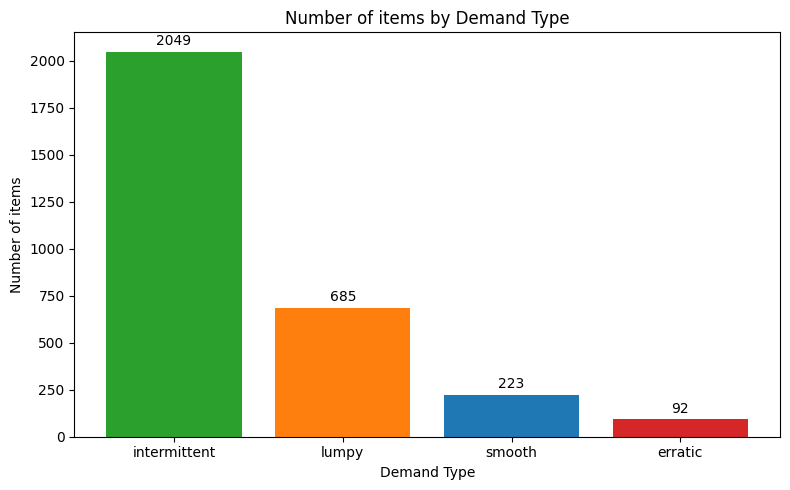

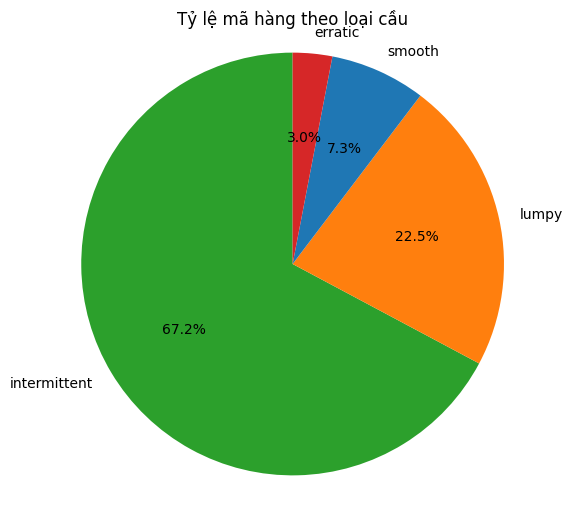

In [ ]:
# Đếm số lượng mã hàng theo demand_type (gộp NaN thành 'unknown')
demand_counts = ABC_demand_classify['demand_type'].fillna('unknown').value_counts()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(demand_counts.index, demand_counts.values, color=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax.set_title('Number of items by Demand Type')
ax.set_ylabel('Number of items')
ax.set_xlabel('Demand Type')

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + max(demand_counts.values) * 0.01, f'{int(h)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Pie chart (tỷ lệ)
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.pie(demand_counts.values, labels=demand_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['tab:green', 'tab:orange', 'tab:blue', 'tab:red', 'gray'])
ax2.set_title('Tỷ lệ mã hàng theo loại cầu')
ax2.axis('equal')
plt.show()